Mejor costo: 1288.7298731712874


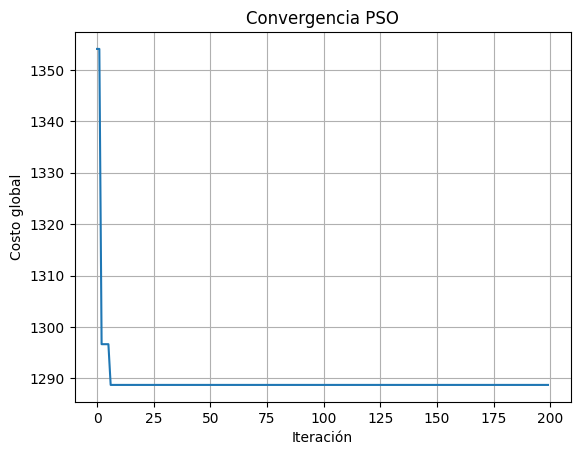

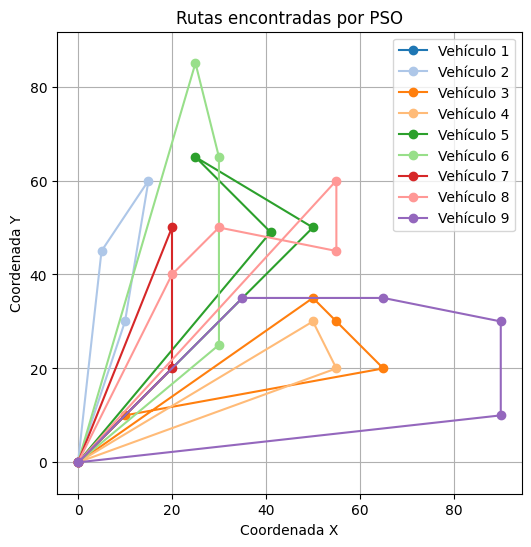

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt


class VRPTW:
    def __init__(self, coordinates, time_windows, demands, vehicle_capacity):
        self.num_customers = len(coordinates)
        self.vehicle_capacity = vehicle_capacity
        self.time_windows = time_windows
        self.demands = demands
        self.coordinates = coordinates
        self.distances = self._compute_distances()

    def _compute_distances(self):
        d = np.zeros((self.num_customers, self.num_customers))
        for i in range(self.num_customers):
            for j in range(self.num_customers):
                x1, y1 = self.coordinates[i]
                x2, y2 = self.coordinates[j]
                d[i, j] = np.hypot(x2 - x1, y2 - y1)
        return d

    def evaluate(self, routes, speed: float = 1000.0) -> float:
        """Devuelve la distancia total si todas las restricciones se cumplen;
        de lo contrario devuelve `inf.

        *speed* convierte la distancia euclídea a tiempo aproximado.
        Si *end_tw* es 999 la ventana se considera abierta.
        """
        total = 0.0
        for route in routes:
            if not route:
                continue
            load = 0
            t = 0  # tiempo actual
            prev = 0  # depósito
            for node in route:
                load += self.demands[node]
                if load > self.vehicle_capacity:
                    return float("inf")

                travel_time = self.distances[prev][node] / speed
                arrival = t + travel_time
                start_tw, end_tw = self.time_windows[node]
                if end_tw == 999:
                    end_tw = 1e9  # ventana abierta
                if arrival > end_tw:
                    return float("inf")
                t = max(arrival, start_tw)
                total += self.distances[prev][node]
                prev = node
            total += self.distances[prev][0]  # regreso al depósito
        return total


class Particle:
    def __init__(self, n_customers: int, n_vehicles: int):
        self.position = np.random.rand(n_customers + 2 * n_vehicles)
        self.velocity = np.zeros_like(self.position)
        self.best_position = self.position.copy()
        self.best_cost = float("inf")


class PSO:
    def __init__(self, vrp: VRPTW, num_particles: int = 30, iterations: int = 200):
        self.vrp = vrp
        self.n_particles = num_particles
        self.iterations = iterations
        self.num_vehicles = 15
        self.particles = [Particle(vrp.num_customers, self.num_vehicles) for _ in range(num_particles)]
        self.global_best_position = None
        self.global_best_cost = float("inf")
        # parámetros PSO
        self.w_start, self.w_end = 0.9, 0.1
        self.cp, self.cg, self.cl, self.cn = 2.0, 2.0, 1.5, 1.5
        self.history = []

    # --- utilidades -----------------------------------------------------
    # ...dentro de la clase PSO...

    def _decode(self, pos):
        n = self.vrp.num_customers
        m = self.num_vehicles
        priority = np.argsort(pos[:n])
        routes = [[] for _ in range(m)]
        ref = pos[n:].reshape(m, 2)
        capacities = [self.vrp.vehicle_capacity] * m

        for cust in priority:
            demand = self.vrp.demands[cust]
            cx, cy = self.vrp.coordinates[cust]
            # Solo vehículos con capacidad suficiente
            feasible = [i for i in range(m) if capacities[i] >= demand]
            if not feasible:
                # Si ningún vehículo puede llevarlo, asigna al primero (solución infactible)
                routes[0].append(cust)
                capacities[0] -= demand
                continue
            # Elige el vehículo más cercano con capacidad suficiente
            d = [np.hypot(cx - ref[i][0], cy - ref[i][1]) if i in feasible else np.inf for i in range(m)]
            idx = int(np.argmin(d))
            routes[idx].append(cust)
            capacities[idx] -= demand
        return [r for r in routes if r]
# ...resto del código...

    # --- PSO principal --------------------------------------------------
    def optimize(self):
        for it in range(self.iterations):
            w = self.w_end + (self.iterations - it) * (self.w_start - self.w_end) / self.iterations
            # evaluación
            for p in self.particles:
                cost = self.vrp.evaluate(self._decode(p.position))
                if cost < p.best_cost:
                    p.best_cost, p.best_position = cost, p.position.copy()
                if cost < self.global_best_cost:
                    self.global_best_cost, self.global_best_position = cost, p.position.copy()
            self.history.append(self.global_best_cost)
            # actualización
            for p in self.particles:
                lbest = random.choice(self.particles).best_position
                nbest = random.choice(self.particles).best_position
                r1, r2, r3, r4 = np.random.rand(4)
                p.velocity = (
                    w * p.velocity
                    + self.cp * r1 * (p.best_position - p.position)
                    + self.cg * r2 * (self.global_best_position - p.position)
                    + self.cl * r3 * (lbest - p.position)
                    + self.cn * r4 * (nbest - p.position)
                )
                p.position += p.velocity
        print(f"Mejor costo: {self.global_best_cost if self.global_best_cost < 1e18 else 'inf'}")

    # --- gráficos -------------------------------------------------------
    def plot_convergence(self):
        plt.plot(self.history)
        plt.title("Convergencia PSO")
        plt.xlabel("Iteración")
        plt.ylabel("Costo global")
        plt.grid(True)
        plt.show()

    def plot_routes(self):
        """
        Dibuja las rutas correspondientes a la mejor partícula global
        encontrada (self.global_best_position).
        """
        if self.global_best_position is None:
            print("No se generó una solución factible.")
            return

        routes = self._decode(self.global_best_position)
        colors = plt.colormaps.get_cmap("tab20")          # hasta 20 colores
        depot_x, depot_y = self.vrp.coordinates[0]

        plt.figure(figsize=(6, 6))
        for i, route in enumerate(routes):
            xs = [depot_x] + [self.vrp.coordinates[n][0] for n in route] + [depot_x]
            ys = [depot_y] + [self.vrp.coordinates[n][1] for n in route] + [depot_y]
            plt.plot(xs, ys, "-o", color=colors(i), label=f"Vehículo {i+1}")

        plt.title("Rutas encontradas por PSO")
        plt.xlabel("Coordenada X")
        plt.ylabel("Coordenada Y")
        plt.legend()
        plt.grid(True)
        plt.axis("equal")          # mantienen escala 1:1
        plt.show()




# Preparación de datos del caso Teherán
# 0 = depósito  (misma convención que Solomon: (x, y, start, end, demanda))
c101_25 = [
    (0.0, 0.0, 0, 1236, 0),  # depósito
    (1006.1, 2187.3, 2, 6, 2),
    (4461.8, 3235.3, 3, 6, 3),
    (-2327.6, 1190.7, 3, 8, 1),
    (-3871.2, 687.7, 3, 5, 1),
    (-1932.6, -1867.7, 3, 7, 2),
    (-3089.9, -139.6, 0, 6, 1),
    (-2289, -169, 2, 8, 3),
    (-3409.6, -1831, 3, 5, 3),
    (-1223.4, -2118.8, 3, 8, 2),
    (2487.8, -1732.2, 1, 2, 1),
    (-2538.7, -1633.9, 2, 4, 1),
    (-4216, 3485.3, 0, 5, 2),
    (1346.8, 1875.2, 0, 8, 3),
    (5489.3, 1989.5, 0, 2, 3),
    (1668.7, 710.3, 2, 8, 2),
    (-2403.8, 596.6, 1, 7, 2),
    (-3727.1, 1393.1, 3, 7, 2),
    (-1140.4, 3747.2, 3, 7, 1),
    (4856.3, -1350.2, 2, 7, 2),
    (6694.6, -705.1, 4, 7, 1),
    (3290.8, 509.1, 0, 7, 2),
    (1921, -2867, 0, 5, 3),
    (6451.2, 1795.1, 1, 7, 4),
    (5180.6, 78.7, 3, 5, 1),
    (-2727.1, -1467, 1, 7, 1),
    (-1227.1, -4284.9, 2, 7, 1),
    (-2007.7, -1349.1, 1, 3, 3),
    (-3742.7, -2713, 2, 6, 2),
    (-627.5, -1923.4, 0, 2, 1),
    (3021.6, -1359.3, 4, 8, 3),
    (2399.9, 381.4, 0, 3, 2),
    (-4636.2, -3012.2, 0, 7, 2),
    (2003.8, 576, 0, 6, 1),
    (3493.2, 180.8, 3, 4, 1),
    (2895.9, 844.5, 3, 5, 5),
    (-3627.7, -2082.4, 0, 5, 1),
    (2707.3, 237.8, 4, 8, 2),
    (5671.2, -280.2, 0, 3, 2),
    (-3126.2, -1850.8, 3, 8, 3),
    (-5529.7, -3383.5, 4, 7, 3),
    (-1656.8, -1306.8, 1, 1, 4),
    (1850.6, -1111.3, 0, 5, 3),
    (2947.1, 1181.6, 0, 7, 1),
    (-2849.7, -1932, 3, 7, 2),
    (2059.2, -1091, 2, 5, 2),
    (-4838.7, 1963.8, 0, 8, 3),
    (-1293.9, -1441.1, 3, 8, 1),
    (-3895.3, -3197.8, 0, 4, 4),
    (-1568.3, 1215.1, 4, 6, 2),
    (713.6, 3227.5, 3, 7, 1),
    (-2087.7, 24.8, 1, 8, 1),
    (-1259, 1895.7, 2, 4, 3),
    (542.6, 1604.8, 0, 8, 2),
    (-2026.4, 1108, 2, 4, 4),
    (-1917.8, 1780.6, 0, 3, 1),
    (-16.8, 3064.5, 1, 4, 3),
    (2436.9, 171.9, 2, 8, 2),
    (-352.5, 3171.6, 0, 7, 2),
    (-1175.4, 3079.4, 0, 8, 1),
    (2433.1, 3942.9, 3, 5, 3),
]


clientes = c101_25

deposito = [(0.0, 0.0, 0, 999, 0)]

# Mantienes el bloque de relax:
cli_relax = [(x, y, 0, 999, d) for x, y, _, _, d in clientes]
coords       = [(x, y) for x, y, *_ in cli_relax]
time_windows = [(s, e) for *_, s, e, _ in [(x, y, s, e, d) for x, y, s, e, d in cli_relax]]
demands      = [d for *_, d in [(x, y, s, e, d) for x, y, s, e, d in cli_relax]]

vrp  = VRPTW(coords, time_windows, demands, vehicle_capacity=20)  # capacidad relajada
pso  = PSO(vrp, num_particles=30, iterations=200)                  # búsqueda moderada
pso.optimize()
pso.plot_convergence()
pso.plot_routes()        





Mejor costo: 1254.3868402669589
Trial 1: cost=1254.39, params=27, 99, 0.72, 0.09, 1.40, 1.70, 0.98, 1.34
Mejor costo: 1241.7641957891765
Trial 2: cost=1241.76, params=32, 194, 0.77, 0.31, 2.87, 2.91, 0.51, 0.77
Mejor costo: 1253.3276754150136
Trial 3: cost=1253.33, params=47, 71, 0.62, 0.45, 2.10, 2.40, 0.79, 1.88
Mejor costo: 1268.097050051531
Trial 4: cost=1268.10, params=21, 225, 0.96, 0.09, 1.25, 2.85, 1.89, 0.58
Mejor costo: 1302.930054750018
Trial 5: cost=1302.93, params=39, 122, 1.00, 0.20, 1.35, 2.86, 1.85, 1.53
Mejor costo: 1314.6725169306396
Trial 6: cost=1314.67, params=35, 190, 0.81, 0.17, 2.56, 2.56, 1.17, 1.82
Mejor costo: 1236.4072519236588
Trial 7: cost=1236.41, params=40, 164, 0.57, 0.36, 2.52, 1.74, 1.69, 0.53
Mejor costo: 1274.2508534101325
Trial 8: cost=1274.25, params=12, 141, 0.61, 0.44, 2.64, 2.51, 1.62, 0.67
Mejor costo: 1318.6031723440333
Trial 9: cost=1318.60, params=21, 181, 0.72, 0.31, 1.09, 2.86, 1.69, 1.25
Mejor costo: 1296.586783626994
Trial 10: cost=1296

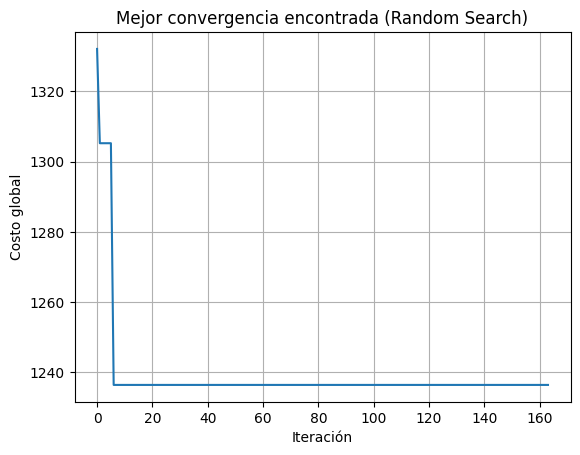

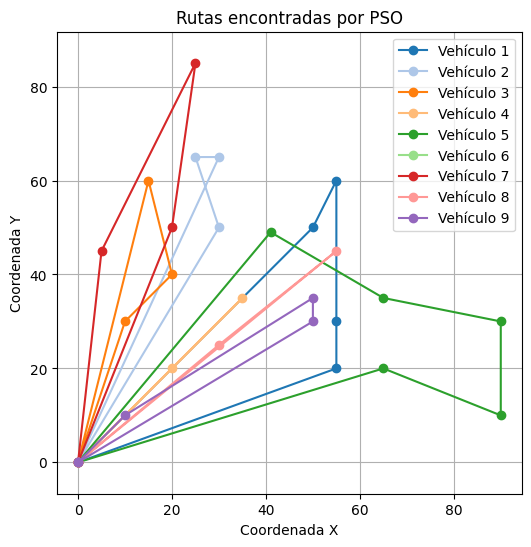

In [4]:

import copy

def random_search_pso(vrp, n_trials=20):
    best_cost = float("inf")
    best_params = None
    best_history = None
    best_routes = None
    best_position = None

    for trial in range(n_trials):
        # Rango de hiperparámetros
        num_particles = np.random.randint(10, 50)
        iterations = np.random.randint(50, 300)
        w_start = np.random.uniform(0.5, 1.0)
        w_end = np.random.uniform(0.05, 0.5)
        cp = np.random.uniform(1.0, 3.0)
        cg = np.random.uniform(1.0, 3.0)
        cl = np.random.uniform(0.5, 2.0)
        cn = np.random.uniform(0.5, 2.0)

        # Instancia PSO con parámetros aleatorios
        pso = PSO(vrp, num_particles=num_particles, iterations=iterations)
        pso.w_start = w_start
        pso.w_end = w_end
        pso.cp = cp
        pso.cg = cg
        pso.cl = cl
        pso.cn = cn

        pso.optimize()
        cost = pso.global_best_cost

        print(f"Trial {trial+1}: cost={cost:.2f}, params={num_particles}, {iterations}, {w_start:.2f}, {w_end:.2f}, {cp:.2f}, {cg:.2f}, {cl:.2f}, {cn:.2f}")

        if cost < best_cost:
            best_cost = cost
            best_params = (num_particles, iterations, w_start, w_end, cp, cg, cl, cn)
            best_history = copy.deepcopy(pso.history)
            best_routes = pso._decode(pso.global_best_position)
            best_position = pso.global_best_position.copy()

    print("\nMejores parámetros encontrados:")
    print(f"num_particles={best_params[0]}, iterations={best_params[1]}, w_start={best_params[2]:.2f}, w_end={best_params[3]:.2f}, cp={best_params[4]:.2f}, cg={best_params[5]:.2f}, cl={best_params[6]:.2f}, cn={best_params[7]:.2f}")
    print(f"Mejor costo: {best_cost:.2f}")

    # Puedes graficar la convergencia del mejor experimento
    plt.plot(best_history)
    plt.title("Mejor convergencia encontrada (Random Search)")
    plt.xlabel("Iteración")
    plt.ylabel("Costo global")
    plt.grid(True)
    plt.show()

    # Graficar la mejor ruta encontrada
    if best_position is not None:
        # Instancia temporal para graficar usando el mejor global encontrado
        pso_best = PSO(vrp)
        pso_best.global_best_position = best_position
        pso_best.plot_routes()

# Ejecuta la búsqueda aleatoria
random_search_pso(vrp, n_trials=10)
# ...existing code...